In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

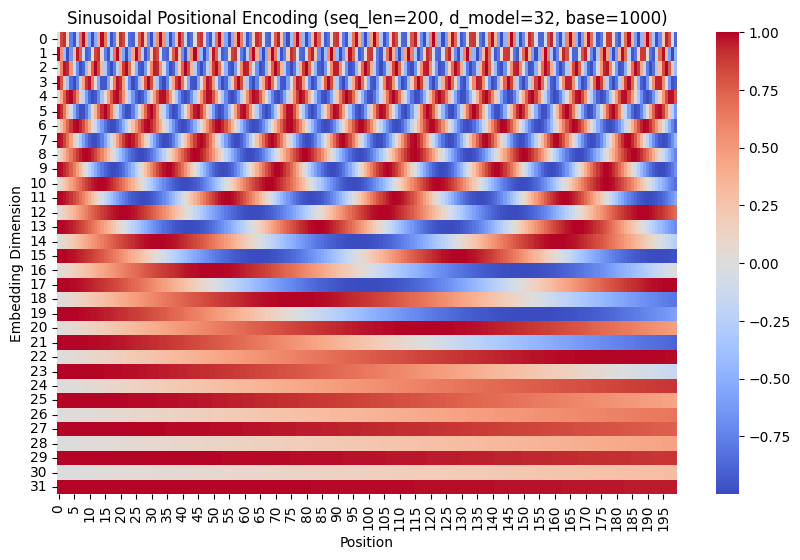

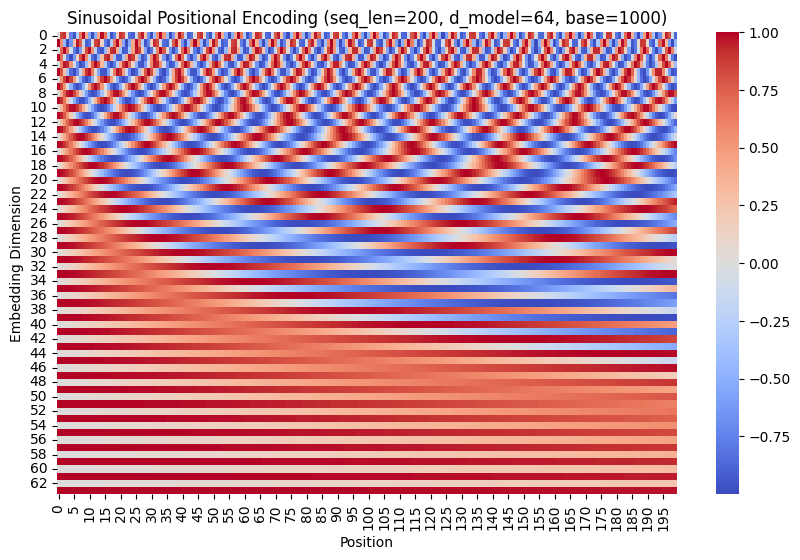

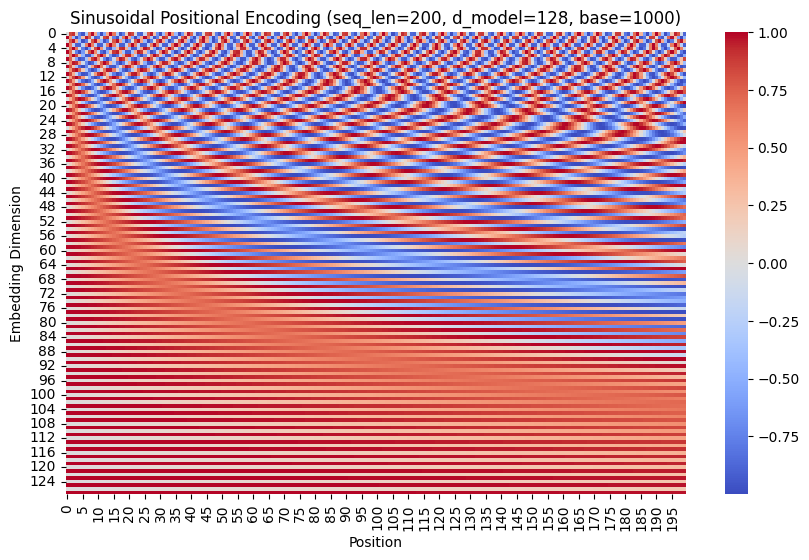

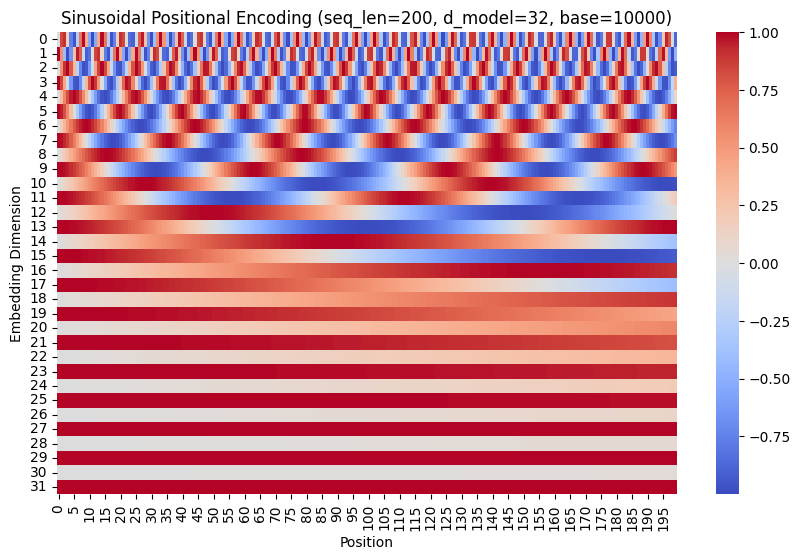

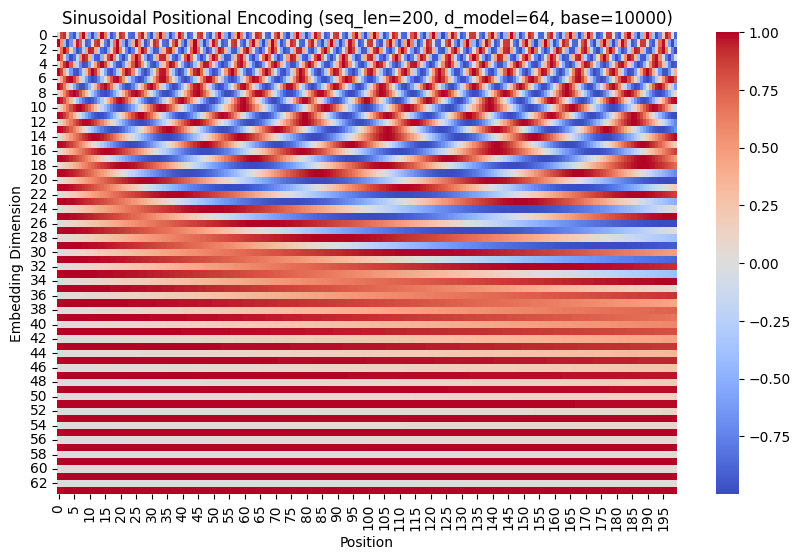

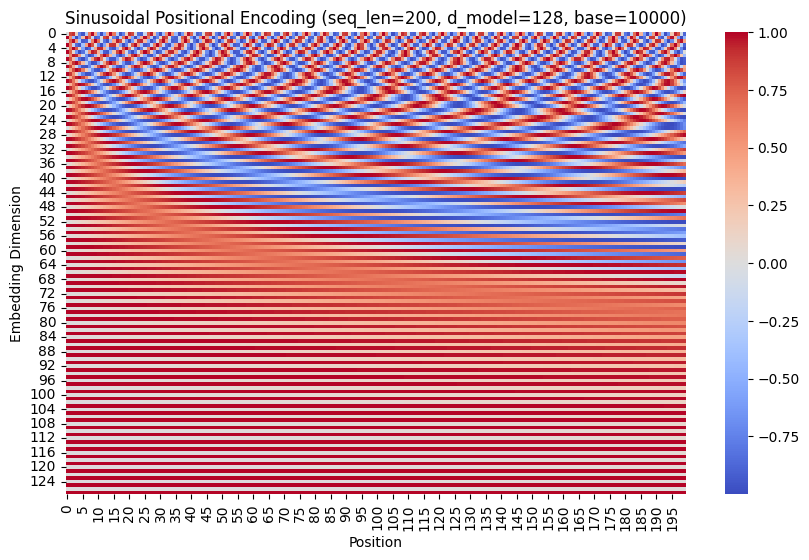

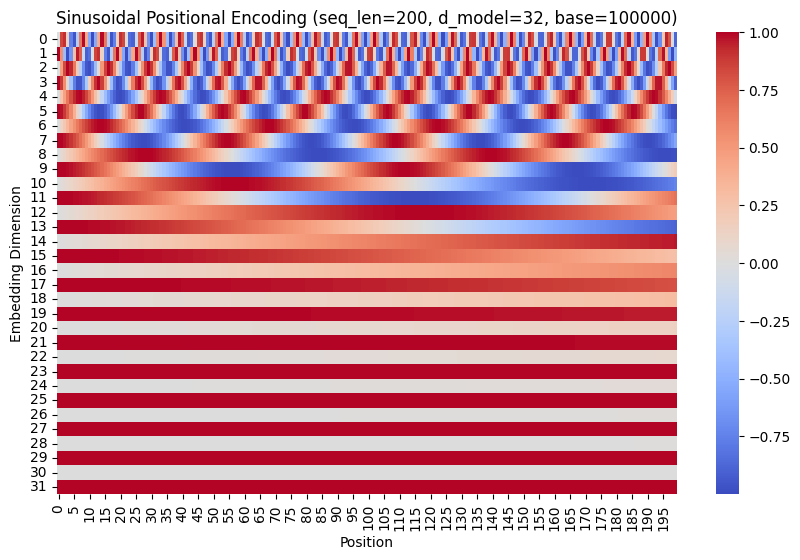

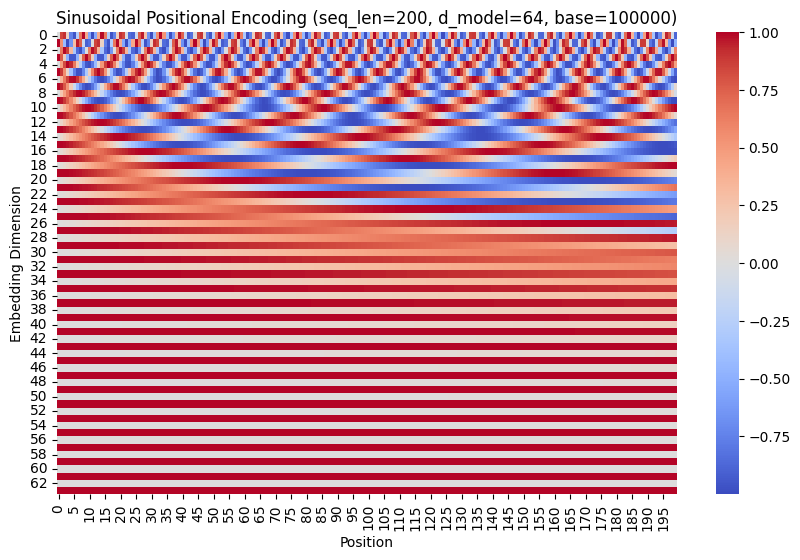

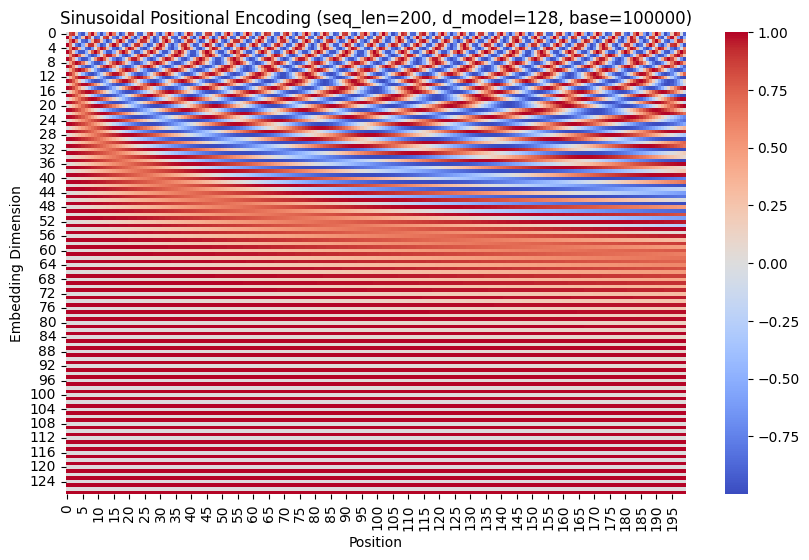

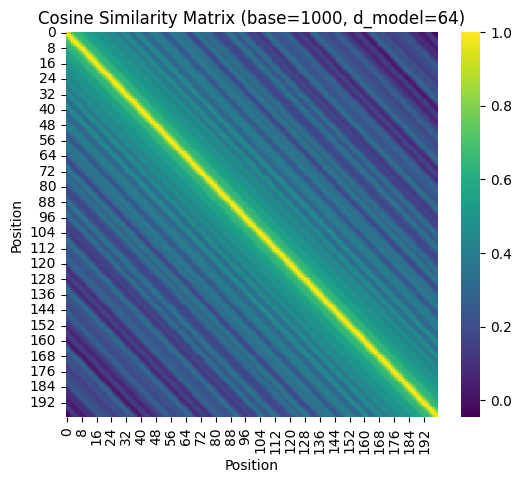

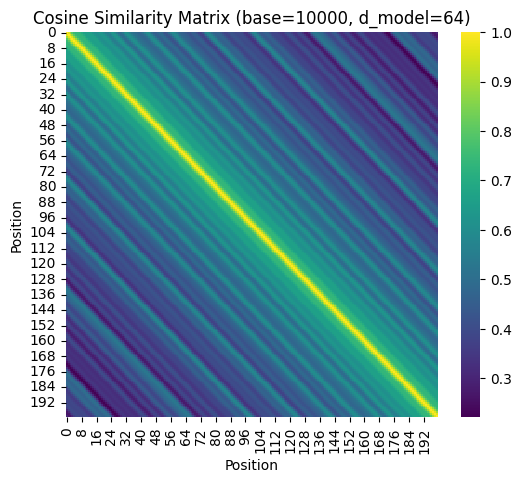

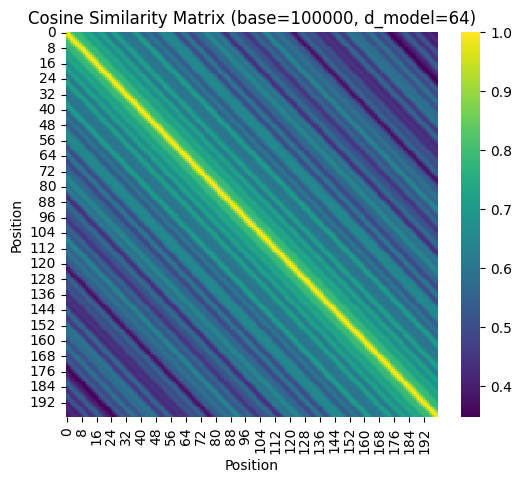

Base Scaling Effects:
Base=  1000 | Avg Local Sim=0.958 | Avg Global Sim=0.351
Base= 10000 | Avg Local Sim=0.966 | Avg Global Sim=0.509
Base=100000 | Avg Local Sim=0.971 | Avg Global Sim=0.604


In [ ]:
# -------------------------------
# 1️⃣ Define sinusoidal embedding
# -------------------------------
def sinusoidal_position_encoding(seq_len, d_model, base=10000):
    pos = np.arange(seq_len)[:, np.newaxis]           # shape (seq_len, 1)
    i = np.arange(d_model)[np.newaxis, :]             # shape (1, d_model)
    angle_rates = 1 / np.power(base, (2 * (i//2)) / np.float32(d_model))
    angles = pos * angle_rates
    pos_encoding = np.zeros_like(angles)
    pos_encoding[:, 0::2] = np.sin(angles[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angles[:, 1::2])
    return pos_encoding

# -------------------------------
# 2️⃣ Visualization function
# -------------------------------
def visualize_positional_encoding(seq_len=100, d_model=64, base=10000):
    pe = sinusoidal_position_encoding(seq_len, d_model, base)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pe.T, cmap="coolwarm", cbar=True)
    plt.title(f"Sinusoidal Positional Encoding (seq_len={seq_len}, d_model={d_model}, base={base})")
    plt.xlabel("Position")
    plt.ylabel("Embedding Dimension")
    plt.show()
    return pe

# -------------------------------
# 3️⃣ Experiment: vary base + dimension
# -------------------------------
bases = [1000, 10000, 100000]
dims = [32, 64, 128]
seq_len = 200

for b in bases:
    for d in dims:
        visualize_positional_encoding(seq_len, d, b)

# -------------------------------
# 4️⃣ Quantitative analysis: smoothness & distinguishability
# -------------------------------
def analyze_similarity(seq_len=200, d_model=64, base=10000):
    pe = sinusoidal_position_encoding(seq_len, d_model, base)
    sim = cosine_similarity(pe)
    avg_local = np.mean([sim[i, i+1] for i in range(seq_len-1)])
    avg_global = np.mean(sim)
    plt.figure(figsize=(6, 5))
    sns.heatmap(sim, cmap="viridis")
    plt.title(f"Cosine Similarity Matrix (base={base}, d_model={d_model})")
    plt.xlabel("Position")
    plt.ylabel("Position")
    plt.show()
    return avg_local, avg_global

results = []
for b in bases:
    local, global_ = analyze_similarity(seq_len=200, d_model=64, base=b)
    results.append((b, local, global_))

print("Base Scaling Effects:")
for b, loc, glob in results:
    print(f"Base={b:>6} | Avg Local Sim={loc:.3f} | Avg Global Sim={glob:.3f}")


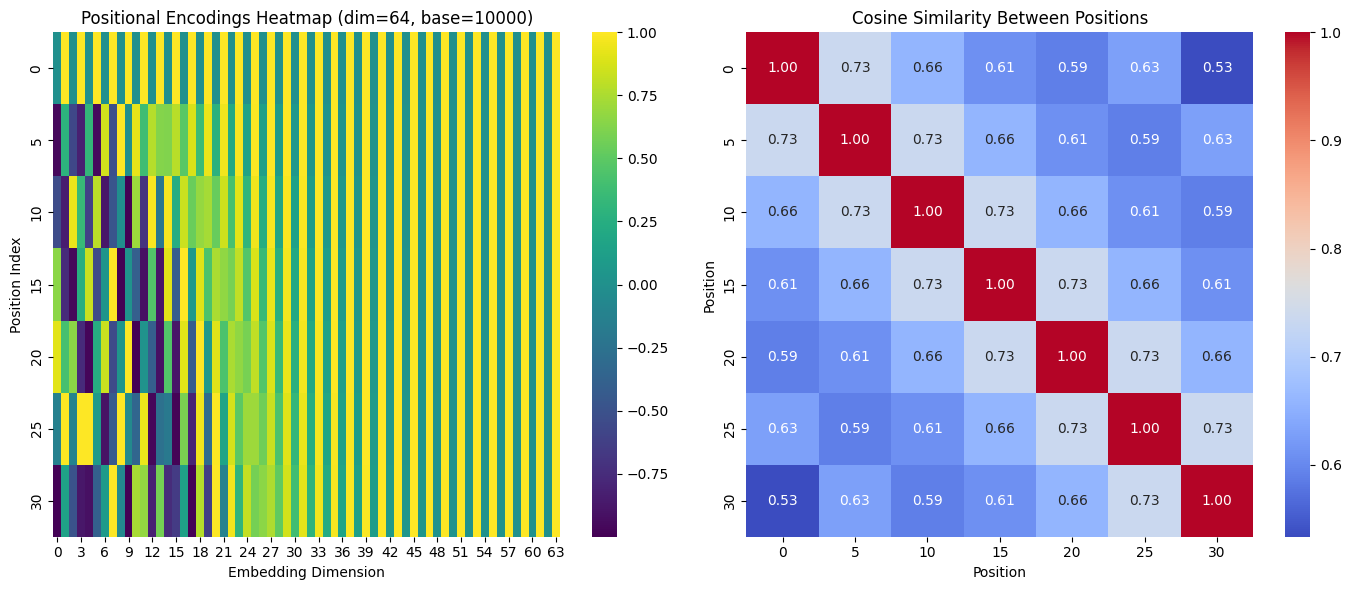

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# --------------------------
# Sinusoidal Positional Encoding Function
# --------------------------
def sinusoidal_encoding(pos, dim, base=10000):
    """
    Compute the sinusoidal positional encoding for given positions.
    pos: numpy array of positions (shape [n_positions, 1])
    dim: embedding dimension
    base: frequency base constant
    """
    angle_rates = 1 / np.power(base, (2 * (np.arange(dim)//2)) / dim)
    angle_rads = pos * angle_rates
    # Apply sin to even indices; cos to odd indices
    sines = np.sin(angle_rads[:, 0::2])
    coses = np.cos(angle_rads[:, 1::2])
    encoding = np.zeros((len(pos), dim))
    encoding[:, 0::2] = sines
    encoding[:, 1::2] = coses
    return encoding

# --------------------------
# Experiment setup
# --------------------------
d_model = 64
positions = np.arange(0, 35, 5)   # positions: 0, 5, 10, 15, 20, 25, 30
base = 10000

# Compute positional encodings
encodings = sinusoidal_encoding(positions.reshape(-1, 1), d_model, base=base)

# Compute cosine similarity between all position embeddings
sim_matrix = cosine_similarity(encodings)

# --------------------------
# Plot: Embedding Heatmap + Similarity Heatmap
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1️⃣ Embedding heatmap
sns.heatmap(encodings, cmap="viridis", ax=axes[0])
axes[0].set_title(f"Positional Encodings Heatmap (dim={d_model}, base={base})")
axes[0].set_xlabel("Embedding Dimension")
axes[0].set_ylabel("Position Index")
axes[0].set_yticklabels(positions)

# 2️⃣ Similarity heatmap
sns.heatmap(sim_matrix, cmap="coolwarm", annot=True, fmt=".2f",
            xticklabels=positions, yticklabels=positions, ax=axes[1])
axes[1].set_title("Cosine Similarity Between Positions")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Position")

plt.tight_layout()
plt.show()


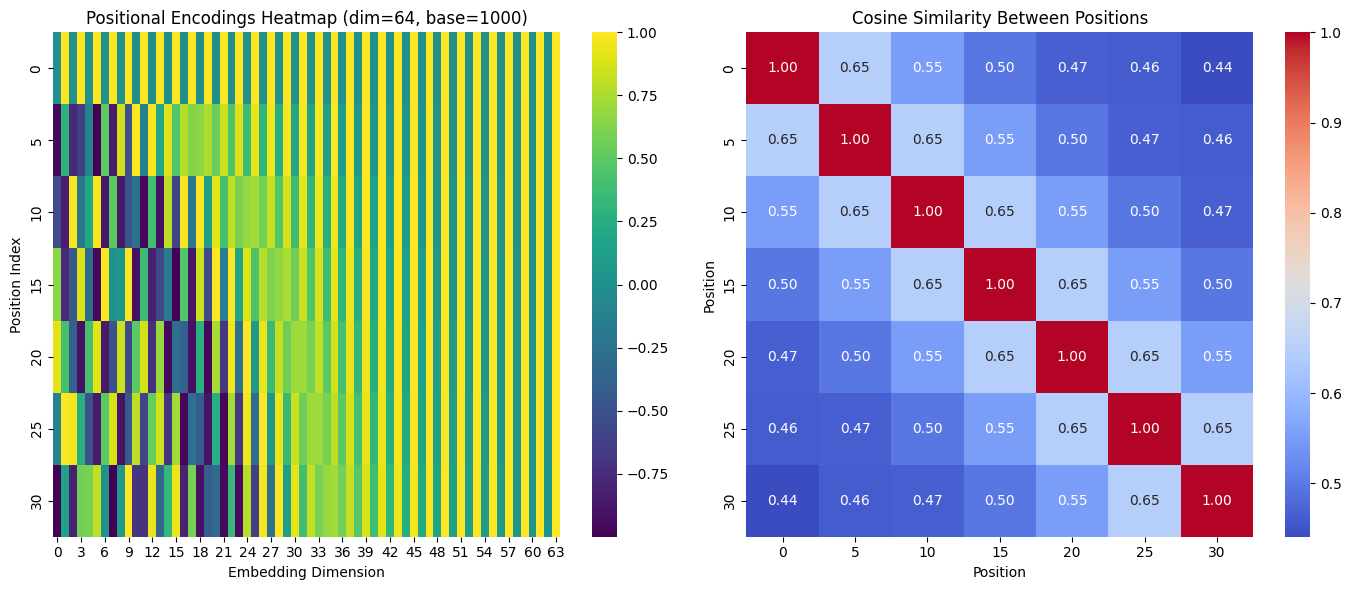

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# --------------------------
# Sinusoidal Positional Encoding Function
# --------------------------
def sinusoidal_encoding(pos, dim, base=10000):
    """
    Compute the sinusoidal positional encoding for given positions.
    pos: numpy array of positions (shape [n_positions, 1])
    dim: embedding dimension
    base: frequency base constant
    """
    angle_rates = 1 / np.power(base, (2 * (np.arange(dim)//2)) / dim)
    angle_rads = pos * angle_rates
    # Apply sin to even indices; cos to odd indices
    sines = np.sin(angle_rads[:, 0::2])
    coses = np.cos(angle_rads[:, 1::2])
    encoding = np.zeros((len(pos), dim))
    encoding[:, 0::2] = sines
    encoding[:, 1::2] = coses
    return encoding

# --------------------------
# Experiment setup
# --------------------------
d_model = 64
positions = np.arange(0, 35, 5)   # positions: 0, 5, 10, 15, 20, 25, 30
base = 1000

# Compute positional encodings
encodings = sinusoidal_encoding(positions.reshape(-1, 1), d_model, base=base)

# Compute cosine similarity between all position embeddings
sim_matrix = cosine_similarity(encodings)

# --------------------------
# Plot: Embedding Heatmap + Similarity Heatmap
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1️⃣ Embedding heatmap
sns.heatmap(encodings, cmap="viridis", ax=axes[0])
axes[0].set_title(f"Positional Encodings Heatmap (dim={d_model}, base={base})")
axes[0].set_xlabel("Embedding Dimension")
axes[0].set_ylabel("Position Index")
axes[0].set_yticklabels(positions)

# 2️⃣ Similarity heatmap
sns.heatmap(sim_matrix, cmap="coolwarm", annot=True, fmt=".2f",
            xticklabels=positions, yticklabels=positions, ax=axes[1])
axes[1].set_title("Cosine Similarity Between Positions")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Position")

plt.tight_layout()
plt.show()


[[1.         0.29196415 0.19627171 0.09238217 0.10007759]
 [0.29196415 1.         0.29196415 0.19627171 0.09238217]
 [0.19627171 0.29196415 1.         0.29196415 0.19627171]
 [0.09238217 0.19627171 0.29196415 1.         0.29196415]
 [0.10007759 0.09238217 0.19627171 0.29196415 1.        ]]


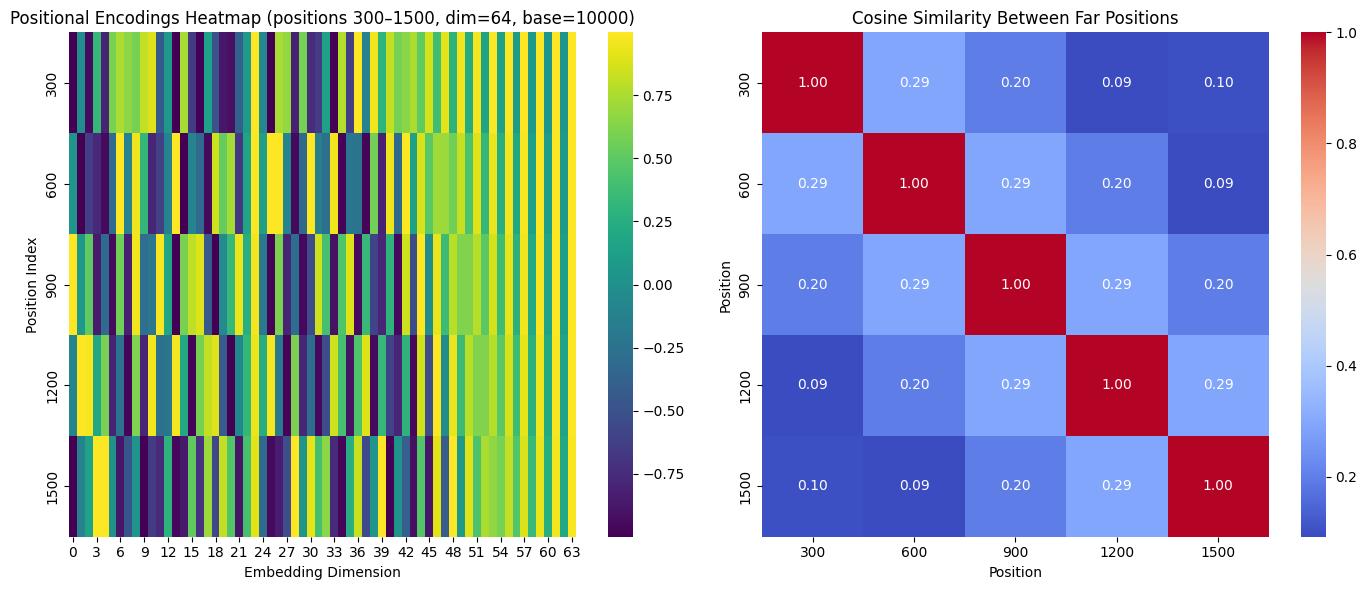

In [17]:
# --------------------------
# Experiment setup
# --------------------------
d_model = 64
positions = np.arange(300, 1800, 300)  # positions: 300, 600, 900, 1200, 1500
base = 10000

# Compute positional encodings
encodings = sinusoidal_encoding(positions.reshape(-1, 1), d_model, base=base)

# Compute pairwise cosine similarity
sim_matrix = cosine_similarity(encodings)

# --------------------------
# Plot heatmaps
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
print(sim_matrix)
# Embedding heatmap
sns.heatmap(encodings, cmap="viridis", ax=axes[0])
axes[0].set_title(f"Positional Encodings Heatmap (positions 300–1500, dim={d_model}, base={base})")
axes[0].set_xlabel("Embedding Dimension")
axes[0].set_ylabel("Position Index")
axes[0].set_yticklabels(positions)

# Cosine similarity heatmap
sns.heatmap(sim_matrix, cmap="coolwarm", annot=True, fmt=".2f",
            xticklabels=positions, yticklabels=positions, ax=axes[1])
axes[1].set_title("Cosine Similarity Between Far Positions")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Position")

plt.tight_layout()
plt.show()

[[ 1.          0.04736781  0.15479302 -0.22182444  0.09474201]
 [ 0.04736781  1.          0.04736781  0.15479302 -0.22182444]
 [ 0.15479302  0.04736781  1.          0.04736781  0.15479302]
 [-0.22182444  0.15479302  0.04736781  1.          0.04736781]
 [ 0.09474201 -0.22182444  0.15479302  0.04736781  1.        ]]


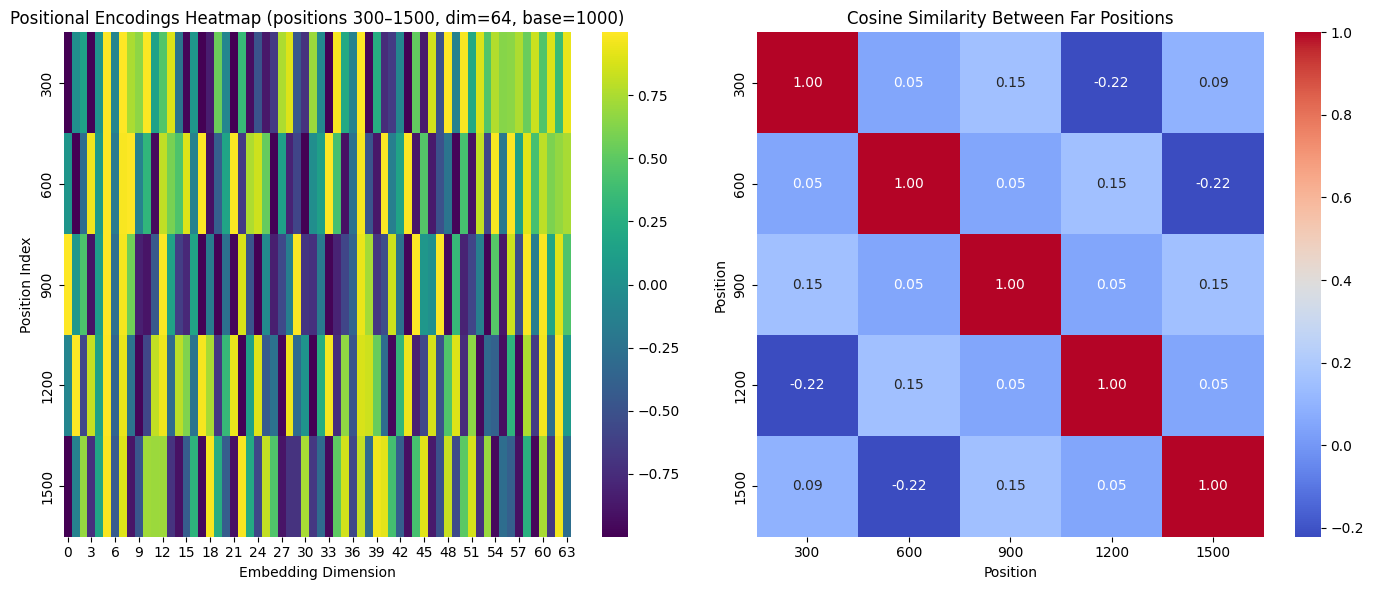

In [18]:
# --------------------------
# Experiment setup
# --------------------------
d_model = 64
positions = np.arange(300, 1800, 300)  # positions: 300, 600, 900, 1200, 1500
base = 1000

# Compute positional encodings
encodings = sinusoidal_encoding(positions.reshape(-1, 1), d_model, base=base)

# Compute pairwise cosine similarity
sim_matrix = cosine_similarity(encodings)

# --------------------------
# Plot heatmaps
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Embedding heatmap
sns.heatmap(encodings, cmap="viridis", ax=axes[0])
axes[0].set_title(f"Positional Encodings Heatmap (positions 300–1500, dim={d_model}, base={base})")
axes[0].set_xlabel("Embedding Dimension")
axes[0].set_ylabel("Position Index")
axes[0].set_yticklabels(positions)
print((sim_matrix))
# Cosine similarity heatmap
sns.heatmap(sim_matrix, cmap="coolwarm", annot=True, fmt=".2f",
            xticklabels=positions, yticklabels=positions, ax=axes[1])
axes[1].set_title("Cosine Similarity Between Far Positions")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Position")

plt.tight_layout()
plt.show()

## Observations

Frequency distribution across dimensions:
Lower-index dimensions in the positional encoding correspond to higher-frequency sinusoids (faster oscillations), while higher-index dimensions correspond to lower-frequency sinusoids (slower oscillations).

Constant phase shift between positions:
The difference between encodings of consecutive positions is periodic and consistent — i.e., the phase shift in each frequency component is constant across positions.

Local vs. distant token variation:
Tokens that are close together (small position difference) mainly differ in the lower-index (high-frequency) components, while tokens that are far apart differ more in the higher-index (low-frequency) components.
→ This suggests that the positional encoding captures relative position at multiple frequency scales.

Effect of the base value (scaling constant):
When the base (often 10,000 in Transformers) is decreased, the periodicity of each frequency increases — meaning the sinusoidal patterns repeat sooner.
As a result, far-apart tokens can end up with similar encodings due to overlapping periodic cycles.

## Conclusions

Multi-scale representation of position:
The sinusoidal encoding scheme represents positions at multiple frequency scales — fine-grained differences captured by low dimensions, and coarse-grained structure captured by higher dimensions.

Relative positioning is implicitly encoded:
Since differences between encodings depend on relative phase shifts, the dot product or distance between encodings can reflect how far apart two positions are — even though the encoding itself is absolute.

Base value controls effective sequence length:
A smaller base causes earlier repetition of sinusoidal cycles, effectively reducing the maximum distinguishable sequence length before encodings begin to overlap.
Conversely, a larger base increases the representable positional range.

Encodings form a structured geometric space:
The positional vectors form a smooth, quasi-periodic manifold where geometric relationships (e.g., cosine similarity) correspond to relative distances in position — a property exploited by the attention mechanism.